<a href="https://colab.research.google.com/github/aiswaryapaul/decision-tree/blob/main/Decision_tree_project(29_04_2025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# step 1 importing the library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# reading the csv file
df = pd.read_csv('/content/heart.csv')


In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
# age = It is the age of patient
# sex = It is Gender of the patient ( 0 for female , 1 for male )
# cp = Chest pain of patient ( 1 level , 2 level )
# trestbps = Blood pressure in resting condition
# chol = cholesterol level at admission at hospital
# fbs = Fasting blood sugar level
# restecg = ECG ( Electrocardio graphy ) level at resting
# thalach = Maximm heart rate achieved during the test
# exang =  Exercise Induced angina  ( Facing any discomfor or not)
# oldpeak = How much ECG changes dusring exercise as compared to rest
# slope = Slope of ECG or ST changes
# ca ( coronary artery ) = The number of major blood vessels ( 0-3)  colored by fluoroscopy
# thal ( thalassemia) = A blood disorder that can damage your heart

# target = whether a patient is having heart disease or not , 1 for Yes , 0 for No

In [ ]:
# step -3 EDA (Exploratory Data Analysis)

df.shape

(303, 14)

In [ ]:
# check in target column how many people will suffer or not

df['target'].value_counts()

# 1 yes
# 0 no

,count
target,
1,165
0,138


In [ ]:
# report of all the columns and their data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
# Step 4 (Data cleaning)

'''
1) check for null values
2) check for duplicate values
3) check for outliers
'''

# check for null values

df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
# null values in numerical column -> replace them with mean / median
# null values in string column -> replace them with mode

In [ ]:
# check for duplicate values

df.duplicated().sum()

np.int64(1)

In [ ]:
# let's drop the 1 duplicate record

df.drop_duplicates(inplace = True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# check the outliers

# first create a list with all the column names

col = list(df.columns)

In [ ]:
col

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

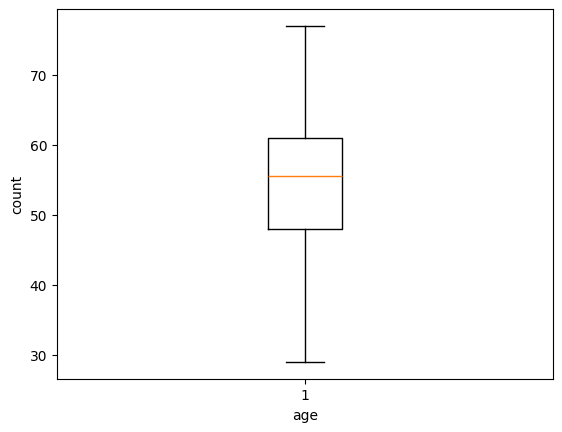

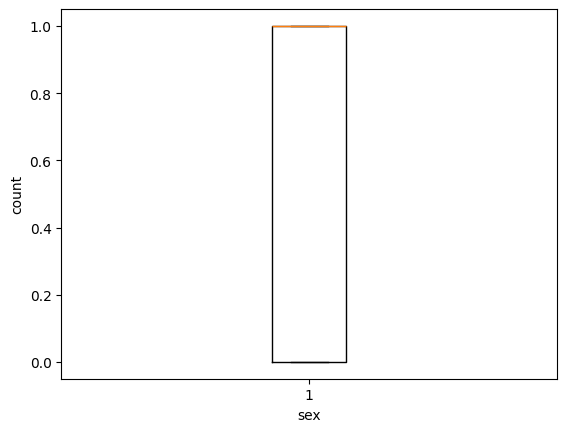

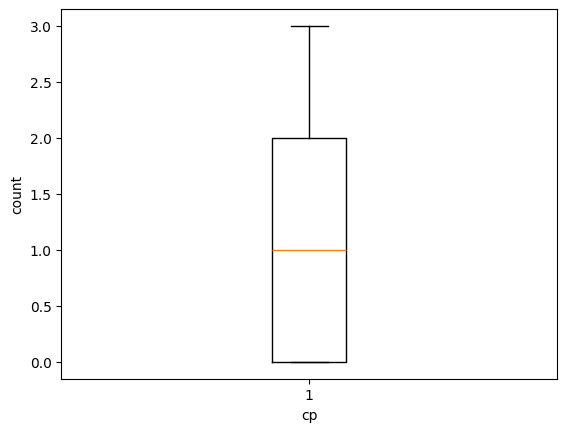

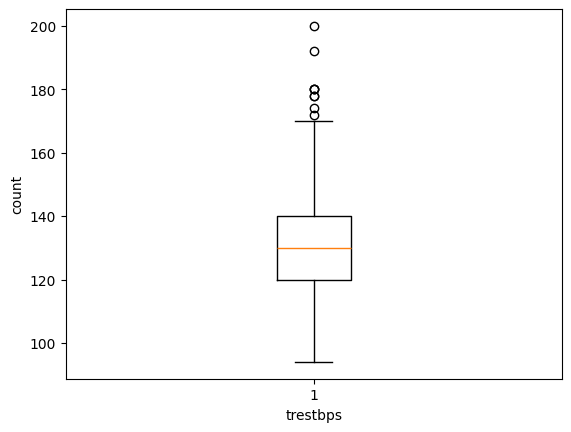

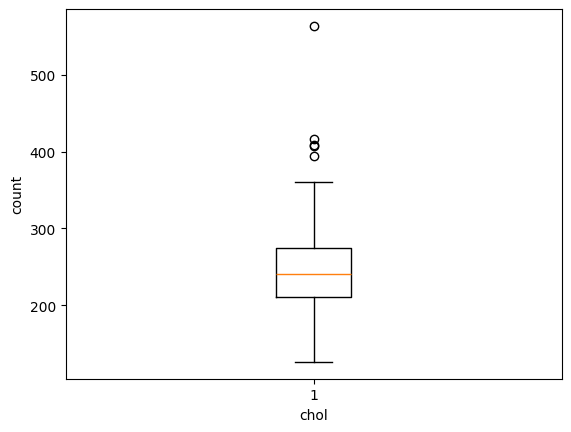

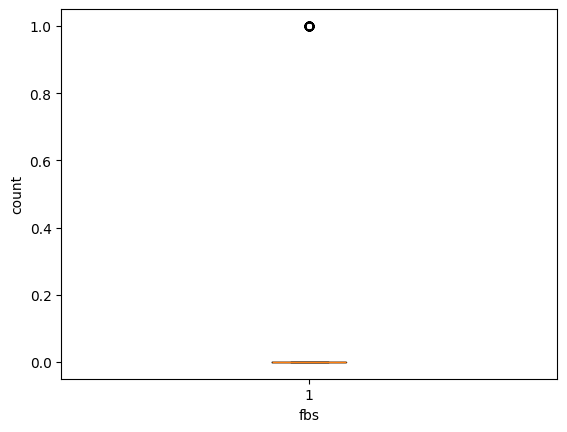

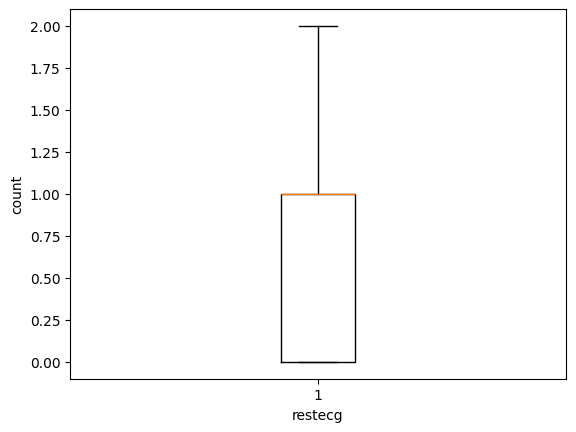

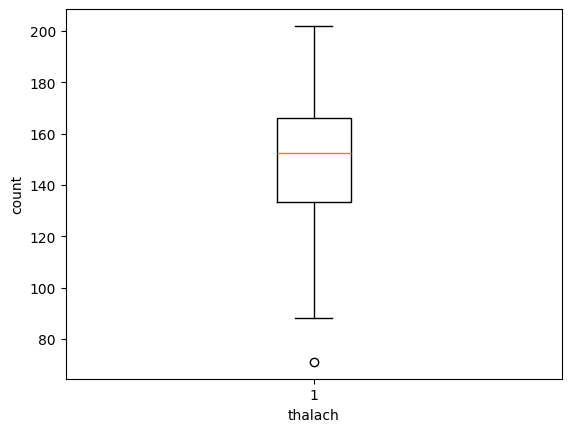

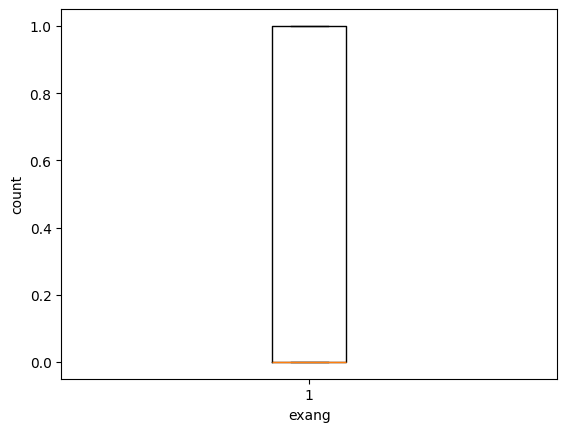

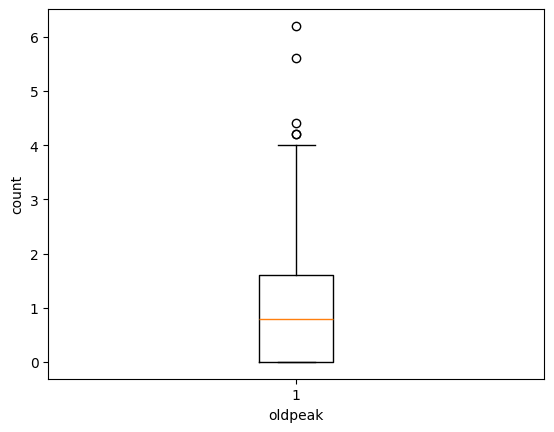

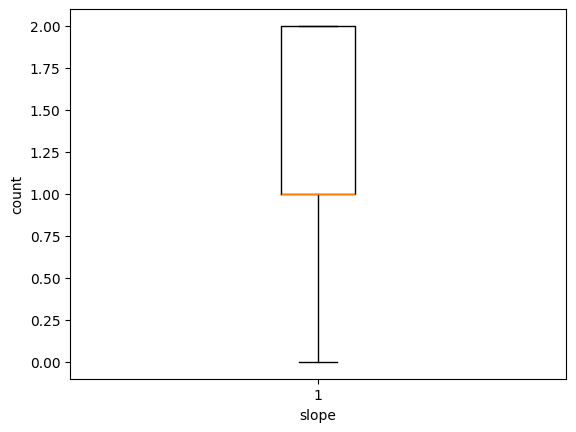

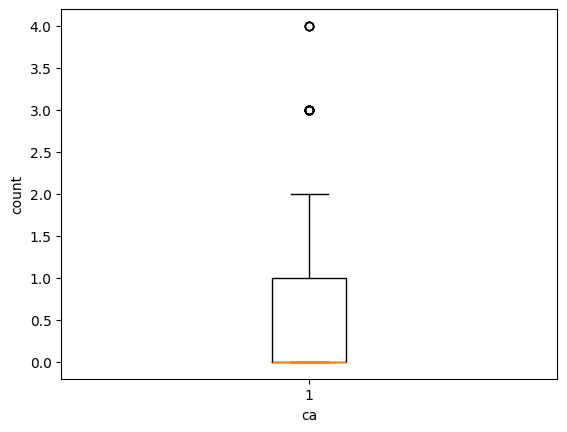

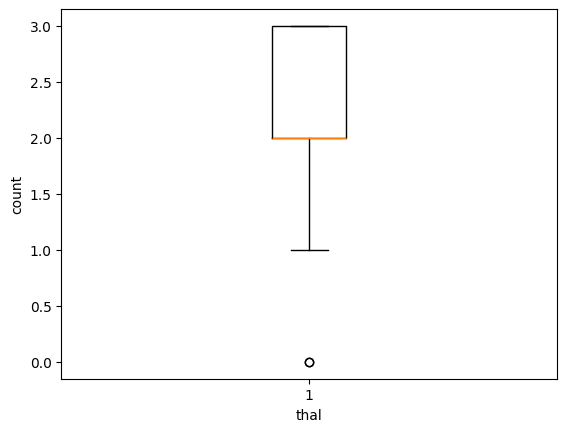

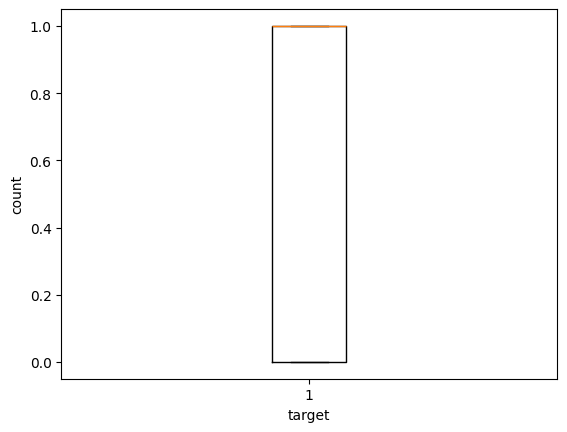

In [ ]:
for i in col:
  if (df[i].dtypes == 'int64' or df[i].dtypes == 'float64'):
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.ylabel('count')
    plt.show()

In [ ]:
# As tree algorithms don't have much impact of outliers then we can skip outlier removal part

In [ ]:
df.shape

(302, 14)

<Axes: >

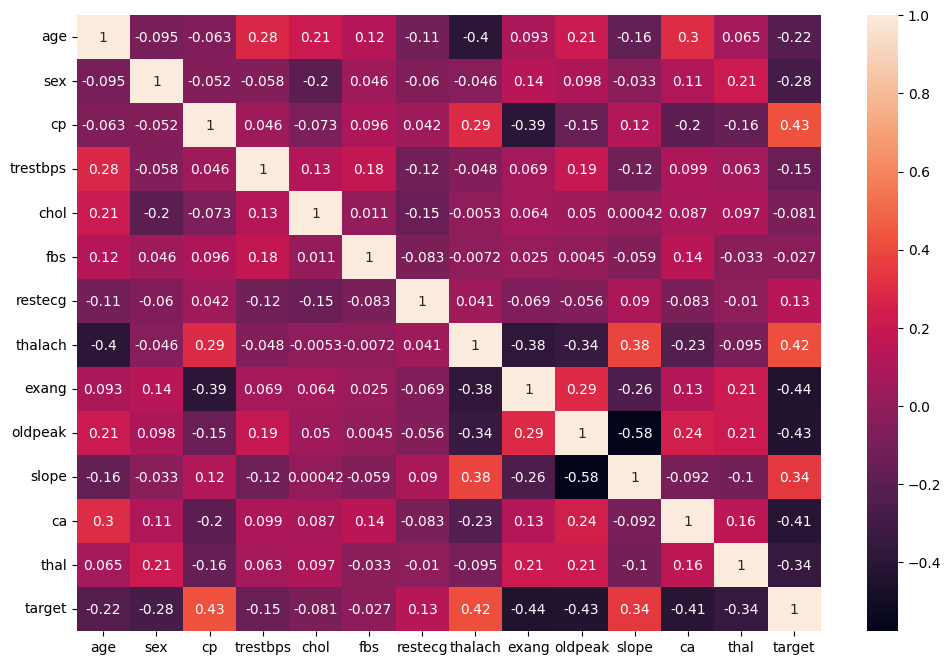

In [ ]:
# check for correlation whether is there any high correlation

plt.figure(figsize = (12,8))
sns.heatmap(df.corr(),annot =True)

In [ ]:
# step -5 (Model Building part)

from sklearn.model_selection import train_test_split # Splitting the dataset into train and test sets

from sklearn.metrics import accuracy_score,confusion_matrix # To evalaute the model performance

from sklearn.tree import DecisionTreeClassifier


In [ ]:
# Divide the data into independent variables and dependent variables

x = df.drop(columns = ['target']) # All the columns except the target column in independent variable x

y = df['target'] # dependent target variable

In [ ]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [ ]:
y

,target
0,1
1,1
2,1
3,1
4,1
...,...
298,0
299,0
300,0
301,0


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x , y, test_size = 0.2,random_state = 60)

In [ ]:
'''
Train means Training
Test means Testing

model - X student

x_train - Training questions (I.D)
y_train - Training answers (D)

x_test - Testing questions (I.D)
y_test - Testing answers (D)

'''

'\nTrain means Training \nTest means Testing \n\nmodel - X student \n\nx_train - Training questions (I.D)\ny_train - Training answers (D)\n\nx_test - Testing questions (I.D)\ny_test - Testing answers (D)\n\n'

In [ ]:
x_train # Independent variable of training

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
255,45,1,0,142,309,0,0,147,1,0.0,1,3,3
222,65,1,3,138,282,1,0,174,0,1.4,1,1,2
35,46,0,2,142,177,0,0,160,1,1.4,0,0,2
273,58,1,0,100,234,0,1,156,0,0.1,2,1,3
230,47,1,2,108,243,0,1,152,0,0.0,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,29,1,1,130,204,0,0,202,0,0.0,2,0,2
99,53,1,2,130,246,1,0,173,0,0.0,2,3,2
70,54,1,2,120,258,0,0,147,0,0.4,1,0,3
65,35,0,0,138,183,0,1,182,0,1.4,2,0,2


In [ ]:
y_train # dependent vraiable of training

,target
255,0
222,0
35,1
273,0
230,0
...,...
72,1
99,1
70,1
65,1


In [ ]:
x_test # Independent variable of testing

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
150,66,1,0,160,228,0,0,138,0,2.3,2,0,1
90,48,1,2,124,255,1,1,175,0,0.0,2,2,2
101,59,1,3,178,270,0,0,145,0,4.2,0,0,3
15,50,0,2,120,219,0,1,158,0,1.6,1,0,2
33,54,1,2,125,273,0,0,152,0,0.5,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,57,1,0,110,201,0,1,126,1,1.5,1,0,1
262,53,1,0,123,282,0,1,95,1,2.0,1,2,3
149,42,1,2,130,180,0,1,150,0,0.0,2,0,2
23,61,1,2,150,243,1,1,137,1,1.0,1,0,2


In [ ]:
y_test # dependent variable of testing

,target
150,1
90,1
101,1
15,1
33,1
...,...
138,1
262,0
149,1
23,1


In [ ]:
model = DecisionTreeClassifier()

In [ ]:
# Train the model
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
# Test out the model

y_pred = model.predict(x_test)

In [ ]:
y_pred # answers given by the model

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0])

In [ ]:
# check the accuracy of the model by comparing y_pred and y_test

accuracy_score(y_pred,y_test)*100

85.24590163934425

In [ ]:
cm = confusion_matrix(y_pred,y_test)

In [ ]:
cm

array([[20,  5],
       [ 4, 32]])

In [ ]:
'''            Actual
                 1      0

Predicted   1   TP     FP

            0   FN     TN


Accuracy = TP+TN / ( TP+TN+FP+FN)
Accuracy =  21+30/ 21+7+3+30
Accuracy = 0.8360655737704918
'''

'            Actual\n                 1      0\n\nPredicted   1   TP     FP\n\n            0   FN     TN\n\n\nAccuracy = TP+TN / ( TP+TN+FP+FN)\nAccuracy =  21+30/ 21+7+3+30\nAccuracy = 0.8360655737704918\n'

[Text(0.5708333333333333, 0.95, 'x[2] <= 0.5\ngini = 0.499\nsamples = 241\nvalue = [114, 127]'),
 Text(0.3277777777777778, 0.85, 'x[11] <= 0.5\ngini = 0.388\nsamples = 114\nvalue = [84, 30]'),
 Text(0.4493055555555555, 0.8999999999999999, 'True  '),
 Text(0.2111111111111111, 0.75, 'x[12] <= 2.5\ngini = 0.5\nsamples = 53\nvalue = [27, 26]'),
 Text(0.1111111111111111, 0.65, 'x[7] <= 146.0\ngini = 0.391\nsamples = 30\nvalue = [8, 22]'),
 Text(0.06666666666666667, 0.55, 'x[8] <= 0.5\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.044444444444444446, 0.45, 'x[0] <= 62.5\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.022222222222222223, 0.35, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.06666666666666667, 0.35, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.08888888888888889, 0.45, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.15555555555555556, 0.55, 'x[0] <= 60.0\ngini = 0.18\nsamples = 20\nvalue = [2, 18]'),
 Text(0.13333333333333333, 0.45, 'gini = 0.0\nsampl

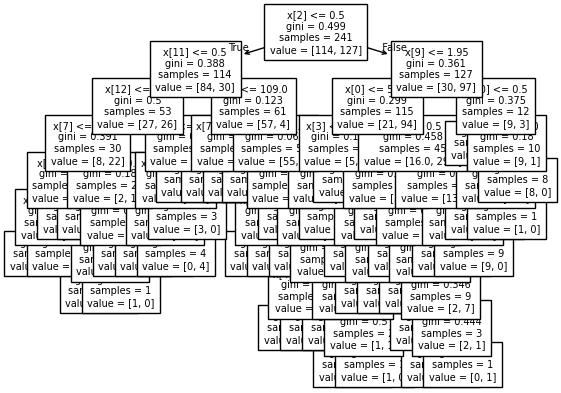

In [ ]:
from sklearn import tree
tree.plot_tree(model, fontsize = 7)

# Testing the different max depth to increase accuracy

In [ ]:
depths = [1,2,3,4,5,6,7,8,9,10,11,12,13]
for i in depths:
  model = DecisionTreeClassifier(max_depth = i, random_state = 60)
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)
  acc = accuracy_score(y_test,y_pred)
  print("Max depth : " , i , "Accuracy score is : ",acc)


Max depth :  1 Accuracy score is :  0.7868852459016393
Max depth :  2 Accuracy score is :  0.7540983606557377
Max depth :  3 Accuracy score is :  0.8852459016393442
Max depth :  4 Accuracy score is :  0.8032786885245902
Max depth :  5 Accuracy score is :  0.8688524590163934
Max depth :  6 Accuracy score is :  0.8524590163934426
Max depth :  7 Accuracy score is :  0.8688524590163934
Max depth :  8 Accuracy score is :  0.8852459016393442
Max depth :  9 Accuracy score is :  0.8852459016393442
Max depth :  10 Accuracy score is :  0.8852459016393442
Max depth :  11 Accuracy score is :  0.8852459016393442
Max depth :  12 Accuracy score is :  0.8852459016393442
Max depth :  13 Accuracy score is :  0.8852459016393442


In [ ]:
model.get_depth()

9

In [ ]:
# small (1-4) : to capture simple patterns
# medium (5-10) : often perfroms the best
# large (15 + ) : may overfit

# Hyperparameter Tuning

* It is a process of finding the best combinations of hyperparameters for a machine learning model so that it performs optimally on unseen (test) data

* The control the learning process
* hyperparameters are settings that you define before training the model

* improves accuracy
* prevents overfitting and underfitting
* Reduces training time

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

# grid search cv

# cv ( cross validation )


CV is a technique to evaluate the performance of the model more reliably -- especially to prevent overfitting

1) K - fold CV

* split the dataset into k equal parts.
* train the model on k-1 , test on the remaining folds
* repeat the process k times , each time with different test fold
* average the results _. give a better estimate of model performance


2) Grid Search CV

* Try every combination of hyperparameters that you provide
* Uses cross validation for each combination
* picks the combination with the best CV score

# grid search cv

# cv ( cross validation )

max_depth : [3,5,10]
criterion : ['gini','entropy']

3 * 2 = 6 combination using 5 - fold cv

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
new_model = DecisionTreeClassifier()

In [ ]:
grid_params = {'criterion': ['gini','entropy'],'max_depth': [1,5,50,100],'random_state':[0,1,2,3,4,5], 'min_samples_split':[2,6,8,9,3,5,22], 'min_samples_leaf':[1,4,6,7,9]}

# criterion : decide how to split the tree
# max_depth : how much depth the tree can go
# min_samples_split : Minimum data points needed to split a node
# # min_sample_leaf = Minimum data points that must be in a leaf node

# min_sample_leaf = 4 , no leaf will be created unless it has atleast 4 samples in it


In [ ]:
gv = GridSearchCV(estimator=new_model , param_grid = grid_params , cv= 3 )

# cv means cross validation , It means your data will be splitted into 3 parts and model will be trained and evaluated 3 times

In [ ]:
gv.fit(x_train,y_train) # training my model

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 5, 50, 100],
                         'min_samples_leaf': [1, 4, 6, 7, 9],
                         'min_samples_split': [2, 6, 8, 9, 3, 5, 22],
                         'random_state': [0, 1, 2, 3, 4, 5]})

In [ ]:
gv.best_params_  # return the best parameters for your model that can give the best accuracy

{'criterion': 'gini',
 'max_depth': 5,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'random_state': 1}

In [ ]:
dt_model = gv.best_estimator_ # create a model with these best paramaters and so #our model can give best accuracy

In [ ]:
y_pred1 = dt_model.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.8852459016393442

In [ ]:
grid_params = {'criterion': ['gini','entropy'],'max_depth': [1,5,50,100],'random_state':[0,1,2,3,4,5], 'min_samples_split':[2,6,8,9,3,5,22], 'min_samples_leaf':[1,4,6,7,9]}
criterion : decide how to split the tree
max_depth : how much depth the tree can go
min_samples_split : Minimum data points needed to split a node

SyntaxError: invalid non-printable character U+00A0 (<ipython-input-1-27c0a53d8abc>, line 4)

In [ ]:
gv = GridSearchCV(estimator=new_model , param_grid = grid_params , cv= 3 )
# cv means cross validation , It means your data will be splitted into 3 parts and model will be trained and evaluated 3 times